# Aufgabe 5 – Welche Zellen tragen die Klassifikation?

Wir interpretieren die **100 gespeicherten Modelle je Methode** aus Aufgabe 4 auf `gated_alive`. Die Frage der Aufgabenstellung ist, ein quantitatives Maß für die vorhersagerelevanten Zellsubsets zu definieren und diese in einer Dimensionsreduktion sichtbar zu machen. Als gemeinsame Karte verwenden wir die bereits berechnete t-SNE-Projektion mit Perplexity 30 aus Aufgabe 2: **500 zufällig gezogene Zellen je Spender, 20 Spender, 37 Marker**. Sie hatte dort den höchsten lokalen Nachbarschaftserhalt unter den untersuchten t-SNE-Einstellungen.

Jede Zelle wird ausschließlich von Modellen bewertet, für die ihr Spender im **äußeren Testset** lag. Die gemeinsame Karte ist explorativ; ihre über alle Spender gelernte Skalierung geht nicht in die Klassifikatoren ein. Für deren Rechnung verwenden wir ausschließlich die gespeicherten Trainings-Scaler. Es findet kein erneutes Klassifikatortraining statt; für Citrus werden die finalen Trainingsbäume deterministisch rekonstruiert.

**Vorbedingungen:** vollständige Exporte von Aufgabe 2 und aller drei Methoden aus Aufgabe 4 sowie die bestehende R-Umgebung `ssbi-citrus`. Das Notebook liest diese Artefakte unverändert und schreibt ausschließlich neue `task5_*`-Dateien. Rohdatenhash, Markerreihenfolge, Originalereignisse und Zell-IDs werden vor der Interpretation geprüft.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "NK_cell_dataset").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
from src.task5_interpretation import run_interpretation, METHODS, PROFILE_MARKERS

TABLES = PROJECT_ROOT / "results" / "tables"
FIGURES = PROJECT_ROOT / "results" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)


## Quantitative Zellsubsets und Auswahlhäufigkeit

Für Zelle $i$ des Spenders $d$ sei $S_d$ die Menge der äußeren Splits, in denen $d$ Testspender war. Wir definieren getrennte Häufigkeiten

$$f_i^+ = |S_d|^{-1}\sum_{s\in S_d}\mathbf{1}\{i\text{ wird in }s\text{ positiv ausgewählt}\},\qquad f_i^- = |S_d|^{-1}\sum_{s\in S_d}\mathbf{1}\{i\text{ wird in }s\text{ negativ ausgewählt}\}.$$

Der Nenner enthält **alle zulässigen Modelle einschließlich Nullmodellen**. Fehlende Ergebnisse führen zu einem Fehler. Wegen der Spendersplits unterscheiden sich die Nenner zwischen Spendern; sie werden nicht pauschal auf 100 gesetzt. Die folgenden nativen Regeln unterscheiden sich zwischen Methoden: gleiche Häufigkeiten sind deshalb **keine gleichen Effektstärken, Zellanteile im Gesamtdatensatz oder Modellgüten**.

| Methode | Quantitative Regel je Modell |
|---|---|
| Lineare Single-Cell-SVM | Zellmargin $m_i=w^Tz_i+b$. Exakt die höchsten $k=\lceil0{,}01N_d\rceil$ Margins des **vollständigen Testspenders** auswählen; Gleichstände nach Originalereignisnummer. Innerhalb dieses Subsets positiv, wenn $m_i>\tau_s$, negativ, wenn $m_i<\tau_s$. $\tau_s$ ist die in Aufgabe 4 innerlich validierte Spenderschwelle. Die niedrigsten Margins werden nicht zusätzlich ausgewählt. |
| CellCNN | $r_{if}=\max(0,w_f^Tz_i+b_f)$. Filter $f$ wählt die Zelle bei $r_{if}>\frac12\max_{j\in T_s}r_{jf}$ aus; $T_s$ enthält sämtliche Ereignisse der tatsächlich zum ausgewählten Netz gehörenden 9/10 inneren Trainingsspender. Positiv bei Auswahl durch mindestens einen Filter mit $a_f=w_{1f}-w_{0f}>0$, negativ analog bei $a_f<0$. Filtermaximum oder Kontrast null selektiert nichts. |
| Citrus | Originalzuordnung zur **nächsten Trainingszelle** und damit zu allen zugehörigen hierarchischen Clustern. $q_i=\sum_j\beta_j\mathbf{1}(i\in C_j)$ über gespeicherte Cluster mit $|\beta_j|>10^{-10}$. Positive Nettoauswahl bei $q_i>10^{-10}$, negative bei $q_i<-10^{-10}$; kleinere Nettowerte sind numerisch neutral. Überlappende und gegenläufige Clustergewichte werden addiert. |

CellCNN kann dieselbe Zelle im selben Split in beide Richtungen auswählen; dafür speichern wir zusätzlich $f_i^{\pm}$. Die positive und negative Häufigkeit dürfen deshalb nicht als disjunkte Anteile addiert werden. Die CellCNN-Halbmaximum-Regel beschreibt einen filterassoziierten **Phänotyp**, nicht die exakt gepoolten Zellen eines konkreten Testbags.

**Paperbezug und Abweichungen:** Das [CellCNN-Paper, Methoden: NK-cell benchmark](../CellCNN.pdf) verwendet ebenfalls filterbezogene Halbmaximum-Subsets, gruppiert ihre Zentroiden über 100 Läufe und berichtet wiederkehrende Zentroidgruppen. Hier ersetzen wir diese zusätzliche Metaclusteranalyse durch direkt vergleichbare OOF-Zellhäufigkeiten auf einer vorhandenen Karte. Das Maximum wird explizit nur aus den jeweiligen Trainingsspendern bestimmt. Die Trennung nach Ausgangsgewicht und die SVM-Richtung relativ zur gespeicherten Spenderschwelle präzisieren die Zuordnung zur tatsächlichen Entscheidung. Diese Analyse repliziert nicht die Zentroidgruppen oder deren 20-von-100-Schwelle aus dem Paper.

## Rechenprüfung vor der biologischen Auswertung

- **SVM:** Der Mittelwert der ausgewählten Margins muss alle 600 gespeicherten Spenderscores bis $10^{-10}$ reproduzieren. Der Mittelwert von $m_i-\tau_s$ rekonstruiert den Abstand zur Entscheidungsschwelle.
- **CellCNN:** Für alle 600 Vorhersagen werden exakt die ursprünglichen fünf Testziehungen mit bis zu 20.000 Zellen reproduziert. Pro Bag gilt $\ell_1-\ell_0=(b_1-b_0)+\sum_f a_f\operatorname{meanTop}_{\lfloor0{,}01N\rfloor}(r_f)$ (Toleranz $10^{-5}$). Erst anschließend werden die fünf Softmax-Wahrscheinlichkeiten gemittelt; diese müssen bis $10^{-6}$ mit dem gespeicherten Score übereinstimmen. Eine Sigmoid-Transformation des gemittelten Logits wäre eine andere Rechnung. Ursprüngliches float32-Lesen, float32-arcsinh und sklearn-Scalerarithmetik werden erhalten.
- **Citrus:** Die 85 nichtleeren finalen Trainingsbäume werden mit dem ursprünglichen R-Sampling aus 1.000 Zellen je Trainingsspender wiederhergestellt; Cluster-IDs, Mindestgröße und alle 37 gespeicherten Zentroidkoordinaten werden geprüft. Die ursprünglichen 1.000 Testzellen je Spender liefern $\overline q_d=\sum_j\beta_j\operatorname{Abundanz}_{dj}$. Mangels gespeichertem Intercept prüfen wir **zentrierte Logits und alle 15 Spenderpaar-Differenzen je Split**, nicht absolute Wahrscheinlichkeiten: $\operatorname{logit}(p_d)-\operatorname{logit}(p_e)=\overline q_d-\overline q_e$ (Toleranz $10^{-8}$). Die 15 numerischen Nullmodelle bleiben enthalten. Es wird kein Intercept geschätzt und keine Regression neu angepasst.

Die Rechenprüfung von CellCNN erfasst zusätzlich, in wie vielen zulässigen Testvorhersagen eine Karten-Zelle in mindestens einem Bag vorkam. Diese Exposition wird separat ausgewiesen; die Phänotyphäufigkeit ist für jede Karten-Zelle in jedem zulässigen Testmodell definiert.

In [2]:
# Vollständiger Interpretationslauf; keine Suche nach Hyperparametern und kein Modelltraining.
results = run_interpretation(PROJECT_ROOT)
frequencies = results["cell_scores"]
checks = results["prediction_checks"]
profiles = results["marker_profiles"]
summary = results["selection_summary"]

check_summary = checks.groupby("method", sort=False).agg(
    n_donor_predictions=("donor_id", "size"),
    maximum_probability_or_margin_error=("score_error", "max"),
    maximum_arithmetic_error=("arithmetic_error", "max"),
    maximum_pairwise_logit_error=("pairwise_logit_error", "max"),
)
display(check_summary)
display(Markdown("Bei Citrus sind absolute Rekonstruktionsfehler bewusst **nicht definiert** (NaN); geprüft werden die Logitdifferenzen. Bei SVM bezeichnet die erste Fehlerspalte Margins, bei CellCNN Wahrscheinlichkeiten."))


SVM/CellCNN: Split 0 rekonstruiert und geprüft.


SVM/CellCNN: Split 1 rekonstruiert und geprüft.


SVM/CellCNN: Split 2 rekonstruiert und geprüft.


SVM/CellCNN: Split 3 rekonstruiert und geprüft.


SVM/CellCNN: Split 4 rekonstruiert und geprüft.


...

Citrus: Split 95 rekonstruiert und geprüft.
Citrus: Split 96 rekonstruiert und geprüft.
Citrus: Split 97 rekonstruiert und geprüft.
Clustering 14000 events


Citrus: Split 98 rekonstruiert und geprüft.
Clustering 14000 events


Citrus: Split 99 rekonstruiert und geprüft.


,n_donor_predictions,maximum_probability_or_margin_error,maximum_arithmetic_error,maximum_pairwise_logit_error
method,,,,
SVM,600,4.440892e-16,3.330669e-16,NaN
CellCNN,600,0.000000e+00,4.887581e-06,NaN
Citrus,600,NaN,2.469136e-12,3.003819e-12


Bei Citrus sind absolute Rekonstruktionsfehler bewusst **nicht definiert** (NaN); geprüft werden die Logitdifferenzen. Bei SVM bezeichnet die erste Fehlerspalte Margins, bei CellCNN Wahrscheinlichkeiten.

In [3]:
display(summary.rename(columns={
    "method": "Methode", "direction": "Richtung",
    "selected_cells": "Zellen mindestens einmal ausgewählt",
    "supported_donors": "Spender mit Unterstützung",
    "mean_selection_fraction": "Mittlere Auswahlfraktion je Spender",
    "minimum_donor_cells": "Minimum ausgewählter Zellen je Spender",
    "maximum_donor_cells": "Maximum ausgewählter Zellen je Spender",
}))
cnn_cells = frequencies.loc[frequencies.method.eq("CellCNN")]
exposure = cnn_cells[["n_test_models", "exposed_models"]].agg(["min", "median", "max"])
display(exposure)
ambiguous_fraction = cnn_cells.groupby("sample_id").ambiguous_frequency.mean().mean()
display(Markdown(
    f"**CellCNN-Doppelauswahl:** mittlere spendergewichtete Häufigkeit {ambiguous_fraction:.4f}; "
    f"{int(cnn_cells.ambiguous_frequency.gt(0).sum())} Karten-Zellen wurden mindestens einmal "
    "im selben Modell in beide Richtungen ausgewählt. Der Expositionszähler bezieht sich auf "
    "ursprüngliche Bags; die Anzahl äußerer Testmodelle bleibt der Nenner der Phänotypkarten."
))


,Methode,Richtung,Zellen mindestens einmal ausgewählt,Spender mit Unterstützung,Mittlere Auswahlfraktion je Spender,Minimum ausgewählter Zellen je Spender,Maximum ausgewählter Zellen je Spender
0,SVM,positive,219,20,0.002645,1,21
1,SVM,negative,434,20,0.006920,6,34
2,CellCNN,positive,1313,20,0.010909,14,175
3,CellCNN,negative,2739,20,0.017182,59,264
4,Citrus,positive,7678,20,0.157020,252,461
5,Citrus,negative,7893,20,0.113259,269,475


,n_test_models,exposed_models
min,12.0,1.0
median,28.0,14.0
max,42.0,35.0


**CellCNN-Doppelauswahl:** mittlere spendergewichtete Häufigkeit 0.0000; 7 Karten-Zellen wurden mindestens einmal im selben Modell in beide Richtungen ausgewählt. Der Expositionszähler bezieht sich auf ursprüngliche Bags; die Anzahl äußerer Testmodelle bleibt der Nenner der Phänotypkarten.

## Dieselben Zellen, dieselbe Karte

Grau bezeichnet Auswahlhäufigkeit null. Farbige Punkte liegen auf denselben vorhandenen t-SNE-Koordinaten, mit gemeinsamer Skala von 0 bis 1. Hohe Häufigkeit bedeutet wiederholte Auswahl durch zulässige Testmodelle. Die Karte kann lokale Phänotypen zeigen; Abstände zwischen weit entfernten t-SNE-Inseln und sichtbare Gruppen sind keine formalen Tests biologischer Zelltypen oder CMV-Assoziationen.

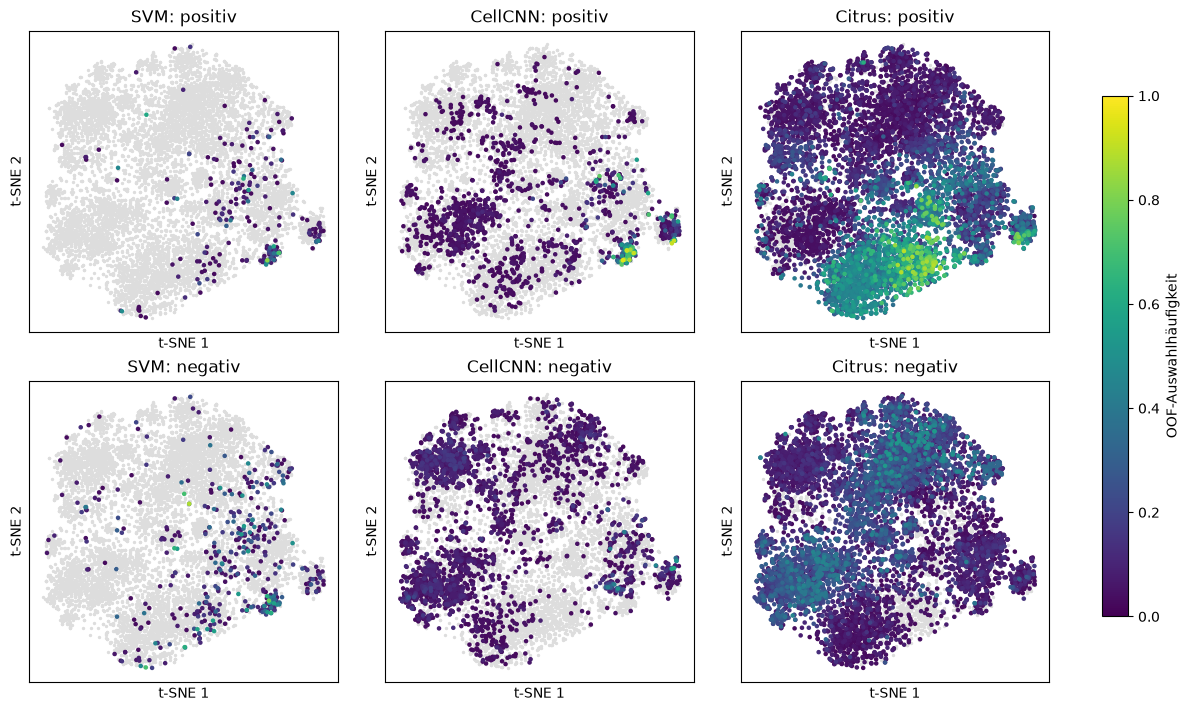

In [4]:
def draw_frequency(ax, frame, column, title):
    ax.scatter(frame.component_1, frame.component_2, s=2, color="#dddddd", rasterized=True)
    selected = frame.loc[frame[column].gt(0)].sort_values(column)
    points = ax.scatter(selected.component_1, selected.component_2, c=selected[column],
                        s=5, cmap="viridis", vmin=0, vmax=1, rasterized=True)
    ax.set(title=title, xlabel="t-SNE 1", ylabel="t-SNE 2", aspect="equal")
    ax.set_xticks([])
    ax.set_yticks([])
    return points

fig, axes = plt.subplots(2, 3, figsize=(12, 7), layout="constrained")
for column, method in enumerate(METHODS):
    frame = frequencies.loc[frequencies.method.eq(method)]
    for row, (direction, german) in enumerate([("positive", "positiv"), ("negative", "negativ")]):
        points = draw_frequency(axes[row, column], frame, direction + "_frequency", f"{method}: {german}")
fig.colorbar(points, ax=axes, label="OOF-Auswahlhäufigkeit", shrink=0.8)
fig.savefig(FIGURES / "task5_selection_maps.png", dpi=200, bbox_inches="tight")
plt.show()

report_fig, report_axes = plt.subplots(1, 3, figsize=(11, 3.4), layout="constrained")
for ax, method in zip(report_axes, METHODS):
    points = draw_frequency(ax, frequencies.loc[frequencies.method.eq(method)], "positive_frequency", method)
report_fig.colorbar(points, ax=report_axes, label="Positive OOF-Auswahlhäufigkeit", shrink=0.85)
report_fig.savefig(FIGURES / "task5_positive_maps_report.png", dpi=220, bbox_inches="tight")
plt.close(report_fig)


## Markerprofile: spendergleich gewichtete Beschreibung

Es wird **keine zusätzliche Schwelle** wie $f_i\geq0{,}5$ eingeführt. Je Spender, Methode und Richtung verwenden wir $f_i$ als Zellgewicht. Der gewichtete Median ist der kleinste beobachtete Markerwert, bei dem mindestens die Hälfte des positiven Gesamtgewichts erreicht ist. Danach medianisieren wir die Spenderprofile gleichgewichtet über Spender mit Unterstützung. Spender ohne ausgewählte Zellen erhalten fehlende Profile, keine Null-Expression.

Die Profile beschreiben die **10.000 Karten-Zellen**, nicht die vollständigen vorhersagerelevanten Populationen aller FCS-Dateien. Insbesondere das seltene SVM-Subset kann pro Spender nur wenige Karten-Zellen umfassen. Als Referenz dient der gleichgewichtige Median der ungewichteten Spender-Medianprofile derselben Karte. Alle 37 Marker werden exportiert; die Darstellung konzentriert sich auf zwölf Marker aus Aufgabe 3. Werte sind $\operatorname{arcsinh}(x/5)$, keine neu standardisierten Modellscores.

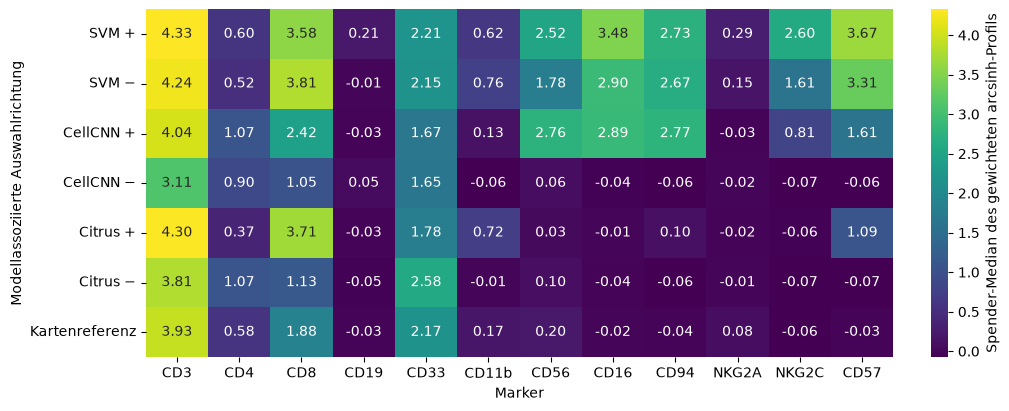

,marker,CD3,CD56,NKG2C,CD57
method,direction,,,,
SVM,positive,4.326,2.516,2.599,3.672
CellCNN,positive,4.037,2.756,0.812,1.609
Citrus,positive,4.302,0.030,-0.055,1.093
Kartenreferenz,all,3.934,0.204,-0.063,-0.029


In [5]:
profile_order = [(method, direction) for method in METHODS for direction in ["positive", "negative"]]
profile_order.append(("Kartenreferenz", "all"))
profile_table = profiles.pivot(index=["method", "direction"], columns="marker", values="value").reindex(profile_order)
heat = profile_table[PROFILE_MARKERS].copy()
heat.index = [f"{method} {dict(positive='+', negative='−', all='').get(direction)}".strip()
              for method, direction in heat.index]
fig, ax = plt.subplots(figsize=(10, 4), layout="constrained")
sns.heatmap(heat, ax=ax, cmap="viridis", annot=True, fmt=".2f",
            cbar_kws={"label": "Spender-Median des gewichteten arcsinh-Profils"})
ax.set(xlabel="Marker", ylabel="Modellassoziierte Auswahlrichtung")
fig.savefig(FIGURES / "task5_marker_profiles.png", dpi=200, bbox_inches="tight")
plt.show()

report_table = profile_table.loc[[(method, "positive") for method in METHODS] + [("Kartenreferenz", "all")],
                                 ["CD3", "CD56", "NKG2C", "CD57"]]
report_table.to_csv(TABLES / "task5_report_marker_table.csv")
display(report_table.round(3))


## Einordnung für den fünfseitigen Bericht

Die nachfolgende Zusammenfassung verwendet die tatsächlich berechneten Profile. Hohe CD3-Werte sprechen für T-Zell-kompatible Anteile; niedriges CD3 zusammen mit einem passenden CD56/CD16/CD94-Profil ist mit NK-Zellen vereinbar. NKG2C und CD57 können zur Beschreibung differenzierter NK-Phänotypen beitragen, beweisen aber weder einen Zelltyp noch eine CMV-verursachte Veränderung. Die Referenz ist die breite Alive-Kartenstichprobe und kein experimentell bestimmtes Negativgate.

Die geringe Zahl unabhängiger Spender und die überlappenden Cross-Validation-Splits erlauben aus Auswahlhäufigkeiten keine Signifikanz- oder Kausalaussagen. Ebenso können stark positive und negative Filterantworten zusammenwirken. Bei Citrus spiegeln geringe oder fehlende Auswahlhäufigkeiten auch die gespeicherten Nullmodelle wider.

**Reportkandidaten:** die drei positiven Karten in einer gemeinsamen Abbildung und die kompakte CD3/CD56/NKG2C/CD57-Tabelle. Negative Karten, Doppelauswahl, vollständige Markerprofile und alle Rechenprüfungen bleiben im Notebook und in den CSV-Exporten. Die Ergebnisse ergänzen den Klassifikationsvergleich aus Aufgabe 4; sie ändern dessen Leistungsmetriken nicht.

In [6]:
reference = profile_table.loc[("Kartenreferenz", "all")]
lines = []
for method in METHODS:
    row = profile_table.loc[(method, "positive")]
    counts = summary.loc[summary.method.eq(method) & summary.direction.eq("positive")].iloc[0]
    descriptions = []
    for marker in ["CD3", "CD56", "NKG2C", "CD57"]:
        relation = "höher" if row[marker] > reference[marker] else "niedriger" if row[marker] < reference[marker] else "gleich"
        descriptions.append(f"{marker} {row[marker]:.2f} ({relation} als Kartenreferenz {reference[marker]:.2f})")
    lines.append(f"**{method}:** Die positive Auswahl beschreibt {int(counts.selected_cells)} mindestens einmal "
                 f"ausgewählte Karten-Zellen aus {int(counts.supported_donors)} Spendern. "
                 f"Die mittlere spendergewichtete Auswahlfraktion beträgt {counts.mean_selection_fraction:.3%}. "
                 + "; ".join(descriptions) + ".")
display(Markdown("\n\n".join(lines)))
print("Exporte:", TABLES.relative_to(PROJECT_ROOT) / "task5_*")
print("Die bestehende Projektion und sämtliche Aufgabe-4-Artefakte wurden ausschließlich gelesen.")


**SVM:** Die positive Auswahl beschreibt 219 mindestens einmal ausgewählte Karten-Zellen aus 20 Spendern. Die mittlere spendergewichtete Auswahlfraktion beträgt 0.265%. CD3 4.33 (höher als Kartenreferenz 3.93); CD56 2.52 (höher als Kartenreferenz 0.20); NKG2C 2.60 (höher als Kartenreferenz -0.06); CD57 3.67 (höher als Kartenreferenz -0.03).

**CellCNN:** Die positive Auswahl beschreibt 1313 mindestens einmal ausgewählte Karten-Zellen aus 20 Spendern. Die mittlere spendergewichtete Auswahlfraktion beträgt 1.091%. CD3 4.04 (höher als Kartenreferenz 3.93); CD56 2.76 (höher als Kartenreferenz 0.20); NKG2C 0.81 (höher als Kartenreferenz -0.06); CD57 1.61 (höher als Kartenreferenz -0.03).

**Citrus:** Die positive Auswahl beschreibt 7678 mindestens einmal ausgewählte Karten-Zellen aus 20 Spendern. Die mittlere spendergewichtete Auswahlfraktion beträgt 15.702%. CD3 4.30 (höher als Kartenreferenz 3.93); CD56 0.03 (niedriger als Kartenreferenz 0.20); NKG2C -0.06 (höher als Kartenreferenz -0.06); CD57 1.09 (höher als Kartenreferenz -0.03).

Exporte: results/tables/task5_*
Die bestehende Projektion und sämtliche Aufgabe-4-Artefakte wurden ausschließlich gelesen.


**Biologische Schlussfolgerung des ausgeführten Laufs:** Bei der positiven SVM-Auswahl sind CD56, NKG2C und CD57 gegenüber der Kartenreferenz deutlich erhöht (2,52/2,60/3,67 gegenüber 0,20/−0,06/−0,03). CellCNN zeigt ebenfalls erhöhte Werte dieser Marker (2,76/0,81/1,61). Zugleich bleibt CD3 in beiden Profilen hoch (4,33 beziehungsweise 4,04; Referenz 3,93). Die gemeinsame Aussage lautet daher nicht „reine CD3-negative NK-Zellpopulation“, sondern eine Auswahl mit NK-assoziierten Markermerkmalen und T-Zell-kompatiblen beziehungsweise heterogenen Anteilen. Die separat zusammengefassten Markermediane beweisen keine gleichzeitige Expression dieser Marker in denselben Zellen. Das positive Citrus-Profil ist eher CD3-/CD8-geprägt, bei niedrigem CD56 und NKG2C; seine breite Karte zeigt zudem, dass mindestens einmalige Auswahl keine enge, stabile Population definiert.

Die stärkere NKG2C-/CD57-Ausprägung der SVM-Auswahl ist keine nachgewiesene biologische Überlegenheit gegenüber CellCNN: Die Methoden verwenden unterschiedliche Auswahlregeln, und von der SVM werden nur 219 der 10.000 Karten-Zellen wenigstens einmal positiv ausgewählt, bei CellCNN 1.313 und bei Citrus 7.678. Spenderprofile der SVM können auf nur einer positiv ausgewählten Karten-Zelle beruhen. Die gemeinsamen Markertrends und die Unterschiede zwischen den Karten sind deshalb eine vorsichtige biologische Ergänzung zu den validierten Klassifikationsleistungen, keine Bestätigung der im Paper berichteten spezifischen NK-Zentroidgruppen.